In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load benchmarks
from hobj import MutatorHighVarBenchmark, MutatorOneshotBenchmark

benchmark1 = MutatorHighVarBenchmark()
benchmark2 = MutatorOneshotBenchmark()

# Benchmark a random guesser

In [3]:
# Load example model – a random guesser
from hobj.learning_models import RandomGuesser

learner = RandomGuesser()

## Experiment 1 benchmark

In [4]:
# Benchmark on Experiment 1
result1 = benchmark1(learner=learner)
print(result1)

LearningCurveBenchmark.LearningCurveBenchmarkResult(msen=0.11344782631802723, msen_sigma=0.001029320465701059, msen_CI95=(0.11137540880220907, 0.11541750060967891), lapse_rate=<xarray.DataArray 'phat' ()> Size: 8B
array(1.), model_statistics=<xarray.LearningCurveStatistics> Size: 103MB
Dimensions:           (subtask: 64, trial: 100, boot_iter: 1000)
Coordinates:
  * subtask           (subtask) <U33 8kB 'MutatorObject000,MutatorObject095' ...
Dimensions without coordinates: trial, boot_iter
Data variables:
    phat              (subtask, trial) float64 51kB 0.532 0.486 ... 0.504 0.482
    varhat_phat       (subtask, trial) float64 51kB 0.0004989 ... 0.0005004
    boot_phat         (boot_iter, subtask, trial) float64 51MB 0.554 ... 0.502
    boot_varhat_phat  (boot_iter, subtask, trial) float64 51MB 0.0004952 ... ...)


MSEn 95% confidence interval: [0.111, 0.115]


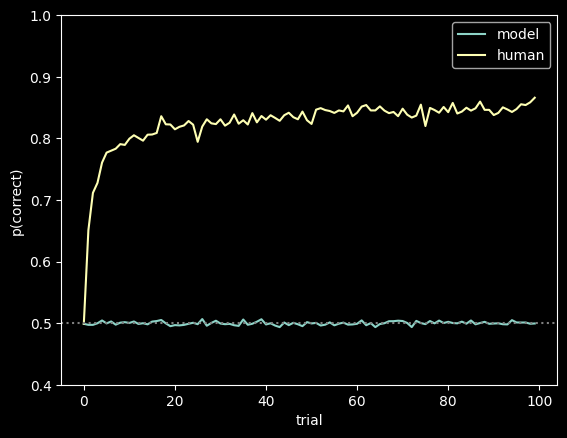

In [5]:
# Plot model behavior
print(f"MSEn 95% confidence interval: [{result1.msen_CI95[0]:.3f}, {result1.msen_CI95[1]:.3f}]")
plt.plot(result1.model_statistics.phat.mean('subtask'), label = 'model')
plt.plot(benchmark1.target_statistics.phat.mean('subtask'), label = 'human')
plt.ylim([0.4, 1])
plt.axhline(0.5, ls = ':', color = 'gray')
plt.legend()
plt.xlabel('trial')
plt.ylabel('p(correct)')
plt.show()

## Experiment 2 benchmark

In [6]:
result2 = benchmark2(learner = learner)
print(result2)

GeneralizationBenchmark.GeneralizationBenchmarkResult(msen=0.17902651379876888, msen_sigma=0.008827749299170323, msen_CI95=(0.1632750537580675, 0.19707395861786794), model_statistics=<xarray.GeneralizationStatistics> Size: 583kB
Dimensions:               (transformation: 36, boot_iter: 1000)
Coordinates:
  * transformation        (transformation) <U26 4kB 'backgrounds | 0.1' ... '...
    transformation_type   (transformation) <U18 3kB 'backgrounds' ... 'scale'
    transformation_level  (transformation) float64 288B 0.1 0.2154 ... 0.5 1.5
Dimensions without coordinates: boot_iter
Data variables:
    phat                  (transformation) float64 288B 0.4981 0.4942 ... 0.4963
    varhat_phat           (transformation) float64 288B 5.878e-05 ... 0.0001155
    boot_phat             (boot_iter, transformation) float64 288kB 0.4847 .....
    boot_varhat_phat      (boot_iter, transformation) float64 288kB 5.704e-05...)


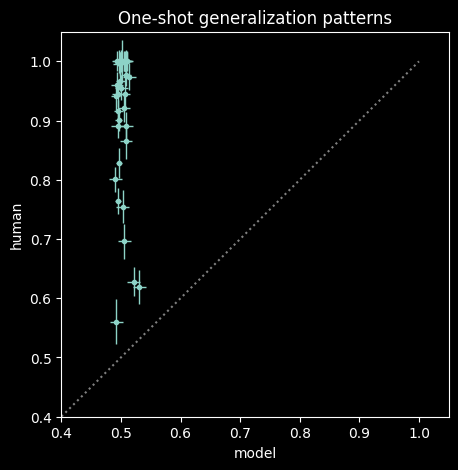

In [7]:
plt.figure(figsize = (5, 5))
x = result2.model_statistics.phat 
xerr = np.sqrt(result2.model_statistics.varhat_phat)

y = benchmark2.target_statistics.phat 
yerr = np.sqrt(benchmark2.target_statistics.varhat_phat)
plt.errorbar(x, y, xerr=xerr, yerr = yerr, lw = 0, elinewidth=1, marker = '.')
plt.plot([0, 1], [0, 1], ls = ':', color = 'gray')
plt.axis([0.4, 1.05, 0.4, 1.05])
plt.xlabel('model')
plt.ylabel('human')
plt.title('One-shot generalization patterns')
plt.show()